# AQI Exploratory Data Analysis

Exploratory look at the backfilled hourly AQI/weather data in the Hopsworks `aqi_features` feature group, before/alongside modeling. Reuses `login()` and `get_latest_features()` from `aqi_predictor.inference` rather than opening a separate connection.

Needs the notebook extras: `pip install -e ".[notebook]"`.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from aqi_predictor.inference import get_latest_features, login

project = login()
# hours is far larger than the backfill window - .tail() just returns everything available.
df = get_latest_features(project, hours=100_000)
df.shape

C:\Users\Ali\Projects\aqi-predictor\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-09-05 15:38:00,499 INFO: Initializing external client


2026-09-05 15:38:00,517 INFO: Base URL: https://eu-west.cloud.hopsworks.ai:443


2026-09-05 15:38:08,834 INFO: Python Engine initialized.



Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/44153
[timing] hopsworks.login(): 9.34s


Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (1.84s) 
[timing] feature view read (get_batch_data): 5.70s


(2189, 25)

## AQI over time

Hourly `european_aqi` across the full backfill period, to spot trends, spikes, and any seasonality at a glance.

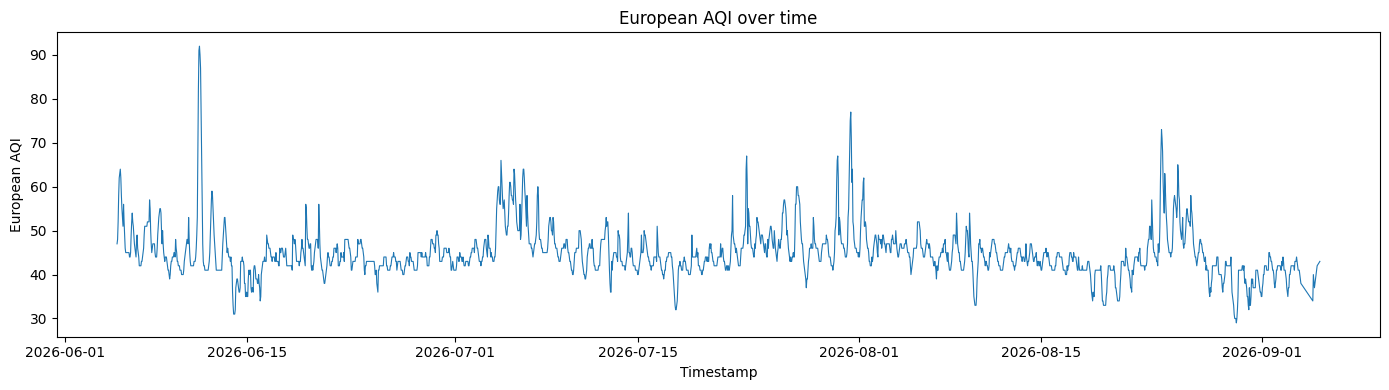

In [2]:
plt.figure(figsize=(14, 4))
plt.plot(df["timestamp"], df["european_aqi"], linewidth=0.8)
plt.title("European AQI over time")
plt.xlabel("Timestamp")
plt.ylabel("European AQI")
plt.tight_layout()
plt.show()

## Correlation: pollutants vs. weather

How PM2.5/PM10/gas concentrations and `european_aqi` relate to temperature, humidity, wind, pressure, and precipitation.

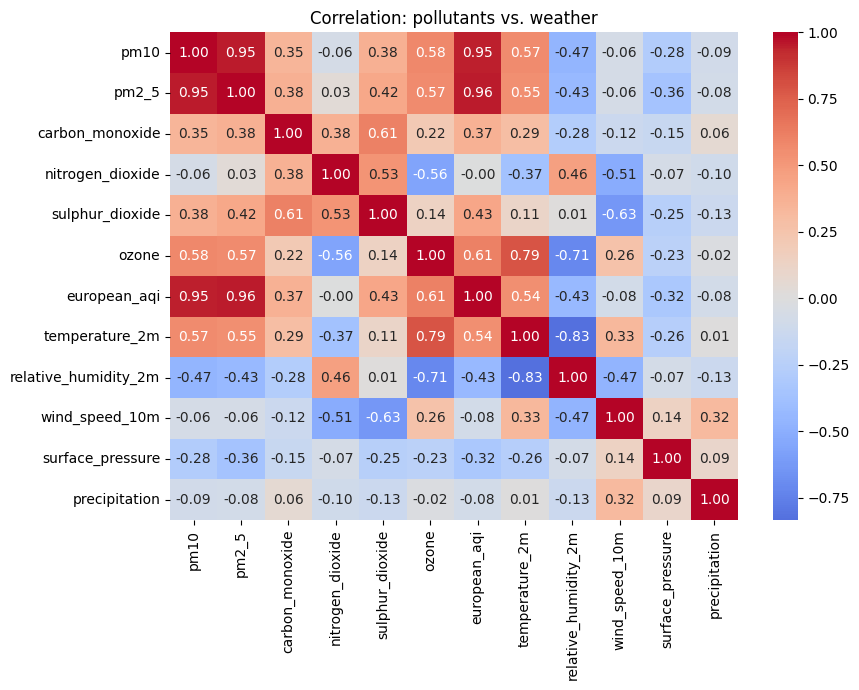

In [3]:
corr_cols = [
    "pm10", "pm2_5", "carbon_monoxide", "nitrogen_dioxide", "sulphur_dioxide", "ozone", "european_aqi",
    "temperature_2m", "relative_humidity_2m", "wind_speed_10m", "surface_pressure", "precipitation",
]
corr = df[corr_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation: pollutants vs. weather")
plt.tight_layout()
plt.show()

## Hour-of-day / day-of-week pattern

Average `european_aqi` by hour and weekday (using the `hour`/`day_of_week` columns already computed in the feature group), to check for daily or weekly cycles such as traffic-driven peaks.

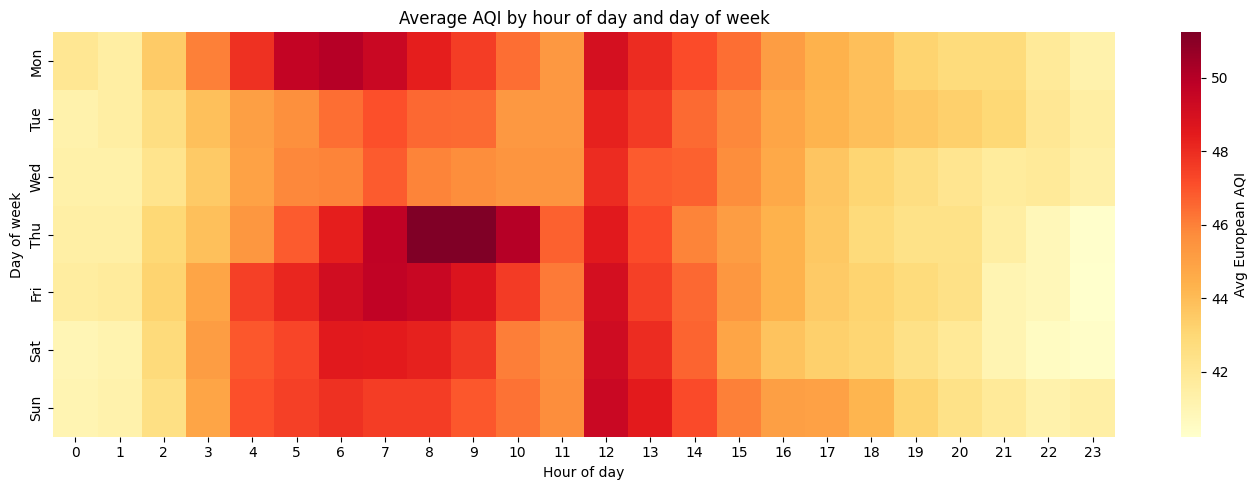

In [4]:
day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
pivot = df.pivot_table(index="day_of_week", columns="hour", values="european_aqi", aggfunc="mean")
pivot.index = [day_names[i] for i in pivot.index]

plt.figure(figsize=(14, 5))
sns.heatmap(pivot, cmap="YlOrRd", cbar_kws={"label": "Avg European AQI"})
plt.title("Average AQI by hour of day and day of week")
plt.xlabel("Hour of day")
plt.ylabel("Day of week")
plt.tight_layout()
plt.show()